# Convolutional Neural Networks (CNN)
author : [Maxime Devanne](https://www.maxime-devanne.com)

### Import libraries

In [ ]:
from sklearn.preprocessing import normalize
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import random

import tensorflow as tf
from tensorflow.keras.utils import to_categorical

## Pokemon images dataset

### Downloading

In [ ]:
!wget 'https://www.maxime-devanne.com/datasets/Pokemon_images/X_train_hr.npy'
!wget 'https://www.maxime-devanne.com/datasets/Pokemon_images/y_train_hr.npy'
!wget 'https://www.maxime-devanne.com/datasets/Pokemon_images/X_test_hr.npy'
!wget 'https://www.maxime-devanne.com/datasets/Pokemon_images/y_test_hr.npy'

--2024-03-12 08:58:25--  https://www.maxime-devanne.com/datasets/Pokemon_images/X_train_hr.npy
Resolving www.maxime-devanne.com (www.maxime-devanne.com)... 213.186.33.4, 2001:41d0:1:1b00:213:186:33:4
Connecting to www.maxime-devanne.com (www.maxime-devanne.com)|213.186.33.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 160546853 (153M)
Saving to: ‘X_train_hr.npy’

X_train_hr.npy      100%[===================>] 153.11M  26.9MB/s    in 6.5s    

2024-03-12 08:58:33 (23.4 MB/s) - ‘X_train_hr.npy’ saved [160546853/160546853]

--2024-03-12 08:58:33--  https://www.maxime-devanne.com/datasets/Pokemon_images/y_train_hr.npy
Resolving www.maxime-devanne.com (www.maxime-devanne.com)... 213.186.33.4, 2001:41d0:1:1b00:213:186:33:4
Connecting to www.maxime-devanne.com (www.maxime-devanne.com)|213.186.33.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6712 (6.6K)
Saving to: ‘y_train_hr.npy’

y_train_hr.npy      100%[===================>]   6.55K

### Loading and preparing data

In [ ]:
# load data
X_train = np.load('X_train_hr.npy')
y_train = np.load('y_train_hr.npy')
X_test = np.load('X_test_hr.npy')
y_test = np.load('y_test_hr.npy')

# get information about image dimensions
width = int(X_train.shape[1])
height = int(X_train.shape[2])
n_channels = int(X_train.shape[3])

### View some images

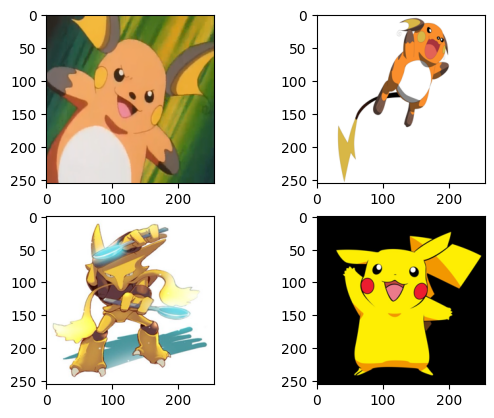

In [ ]:
plt.subplot(221)
plt.imshow(X_train[0])
plt.subplot(222)
plt.imshow(X_train[1])
plt.subplot(223)
plt.imshow(X_train[2])
plt.subplot(224)
plt.imshow(X_train[3])
# show the plot
plt.show()

### Normalize the data so that each pixel is between 0 and 1

In [ ]:
# divide by 255 so everything is in [0;1]
x_train = X_train/255
x_test = X_test / 255

### Transform labels into "one-hot" vectors

In [ ]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

## Train the convolutional neural network which corresponds to slide 55

### Create the input layer which has the same shape as that of an instance in `x_train`

In [ ]:
input_shape = x_train.shape[1:]

input_layer = tf.keras.layers.Input(input_shape)

### Create a hidden convolutional layer that contains 8 filters with the `relu` activation

In [ ]:
# padding: 'valid' -> we do not fill the input image so the convolution reduces the size of the image
#          'same'  -> we fill the input image to keep its size after the convolution
padding = 'same'

# specify stride size
stride = 1

# specify filter size (or kernel): (3,3) means 3x3
kernel_size = (3,3)

# specify filter numbers
filters = 8

# specify ReLU activation function
activation = 'relu'

# create the 2D convolutional layer by specifying its hyper-parameters and link it to the input layer
hidden_conv_layer_1 = tf.keras.layers.Conv2D(filters=filters,
                                          kernel_size=kernel_size,strides=stride,
                                          padding=padding,activation=activation)(input_layer)

### Link a max pooling to the convolutional layer

In [ ]:
# specify pooling size: (2,2) means 2x2
pool_size = (2,2)

# specify stride
stride = 2

# specify padding
padding = 'valid'

# create the Max Pooling operation for 2D (for images it's often 2D)
pooling_conv_layer_1 = tf.keras.layers.MaxPooling2D(pool_size = pool_size, strides = stride,
                                          padding=padding)(hidden_conv_layer_1)

### Flatten the output of pooling

In [ ]:
# we transform the output of the pooling (which is an image) into a vector
flattened_layer_1 = tf.keras.layers.Flatten()(pooling_conv_layer_1)

### Create the output layer

In [ ]:
# This layer corresponds to the classification
# so it contains C neurons with C being the number of classes
# it uses the softmax activation function
# this layer takes as input the flattened layer (flattened)

nb_classes = y_train.shape[1]

output_layer = tf.keras.layers.Dense(units=nb_classes,activation='softmax')(flattened_layer_1)

### Create the model now

In [ ]:
model_cnn = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

### View model information

In [ ]:
model_cnn.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 255, 255, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 255, 255, 8)       224       
                                                                 
 max_pooling2d (MaxPooling2  (None, 127, 127, 8)       0         
 D)                                                              
                                                                 
 flatten (Flatten)           (None, 129032)            0         
                                                                 
 dense (Dense)               (None, 12)                1548396   
                                                                 
Total params: 1548620 (5.91 MB)
Trainable params: 1548620 (5.91 MB)
Non-trainable params: 0 (0.00 Byte)
_______________________

### Choose the optimization algorithm with a learning rate of 0.01

In [ ]:
learning_rate = 0.001
optimizer_algo = tf.keras.optimizers.Adam(learning_rate=learning_rate)

### Choose the cost function you want to optimize: (Categorical Cross-Entropy)

In [ ]:
cost_function = tf.keras.losses.categorical_crossentropy

### Compile the model by indicating to it that we also want to measure the accuracy

In [ ]:
model_cnn.compile(loss=cost_function,optimizer=optimizer_algo, metrics=['accuracy'])

### Specify the fact that we want to save the best model on the valdiation set

In [ ]:
model_checkpoint = tf.keras.callbacks.ModelCheckpoint('best-model.h5', monitor='val_loss', save_best_only=True)

## Training

### Choose the batch size and the number of epochs

In [ ]:
mini_batch_size = 256
nb_epochs = 500

### Train by specifying to use part of the train for the validation of hyper-parameters

Be patient :-)

In [ ]:
percentage_of_train_as_validation = 0.3
history_cnn = model_cnn.fit(x_train,y_train,batch_size=mini_batch_size,
                    epochs=nb_epochs,verbose=False,
                    validation_split=percentage_of_train_as_validation,
                    callbacks=[model_checkpoint])

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


### Plot the variation of the error rate on the train and on the validation set according to the number of epochs

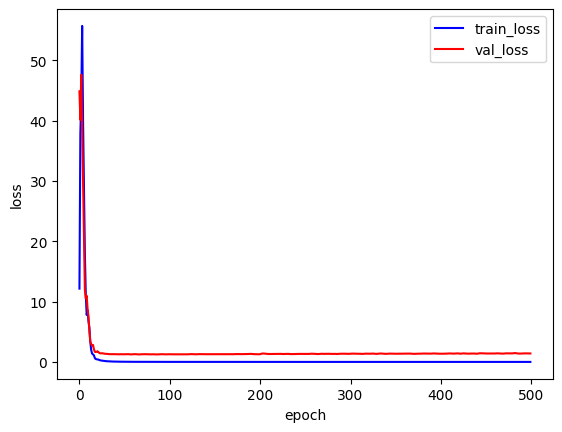

In [ ]:
history_dict = history_cnn.history
loss_train_epochs = history_dict['loss']
loss_val_epochs = history_dict['val_loss']

plt.figure()
plt.plot(loss_train_epochs,color='blue',label='train_loss')
plt.plot(loss_val_epochs,color='red',label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.savefig('epoch-loss.pdf')
plt.show()
plt.close()

### Choose the saved model

In [ ]:
model_cnn = tf.keras.models.load_model('best-model.h5')

### Evaluate the saved model on train and test

In [ ]:
loss,acc = model_cnn.evaluate(x_train,y_train,verbose=False)

print("Accuracy on train:",acc)

loss,acc = model_cnn.evaluate(x_test,y_test,verbose=False)

print("Accuracy on test:",acc)

Accuracy on train: 0.8894289135932922
Accuracy on test: 0.5970873832702637


**=>This is our first CNN!**

## **Exercices**

In this exercice, the goal is to build, train and evaluate the model of slide 56 (ignoring the dropout). Particularly, you have to:


*   Build the model
*   Plot the variation of the accuracy (not only the loss) as a function of the number of epochs (so use 'accuracy' instead of 'loss')
*   Display the summary of your model
*   Evaluate your model



In [ ]:
# Your code here

 ### Correction :

#### Build the model of slide 56 ignoring the dropout

In [ ]:
# restart keras and tesnorflow session
tf.keras.backend.clear_session()

# get the jumber of classes
nb_classes = y_train.shape[1]

# create the input layer which has the same shape as an image
input_shape = x_train.shape[1:]
input_layer = tf.keras.layers.Input(input_shape)

# create the first convolution layer and link it to the input layer
# don't forget to specify the hyper-parameters:
# number of filters, padding, filter size, stride, activation
hidden_conv_layer_1 = tf.keras.layers.Conv2D(filters=10, padding='valid',
                                          kernel_size=(5,5), strides=1,
                                         activation='relu')(input_layer)
# create the max pooling operation which takes the first convolution as input
hidden_pooling_layer_1 = tf.keras.layers.MaxPooling2D(pool_size=(2,2),strides=2,
                                                  padding='valid')(hidden_conv_layer_1)
# create the second convolution which takes as input the previous pooling
# don't forget to specify the hyperparameters
hidden_conv_layer_2 = tf.keras.layers.Conv2D(filters=20, padding='valid',
                                         kernel_size=(5,5),strides=1,
                                         activation='relu')(hidden_pooling_layer_1)
# create the max pooling which is linked to the previous convolution
hidden_pooling_layer_2 = tf.keras.layers.MaxPooling2D(pool_size=(2,2),strides=2,
                                            padding='valid')(hidden_conv_layer_2)

# ignore the dropout at this session
# we must now flatten the image using the layer Flatten
# which is related to the previous pooling
flatenned_layer_2 = tf.keras.layers.Flatten()(hidden_pooling_layer_2)

dense_layer = tf.keras.layers.Dense(units=100,activation='relu')(flatenned_layer_2)

# create the output layer which contains an equal number of neurons
# to the number of classes in the dataset
output_layer = tf.keras.layers.Dense(units=nb_classes,activation='softmax')(dense_layer)

# create the model by specifying input and output
model_cnn2 = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

# choose learning rate
learning_rate = 0.001

# choose the optimization algorithm by specifying the learning rate
optimizer_algo = tf.keras.optimizers.Adam(learning_rate=learning_rate)

# choose the cost function: categorical cross entropy
cost_function = tf.keras.losses.categorical_crossentropy

# compile the model by specifying that we want to monitor the accuracy
model_cnn2.compile(loss=cost_function,optimizer=optimizer_algo, metrics=['accuracy'])

# choose batch size
mini_batch_size = 256

# choose number of epochs
nb_epochs = 500

# specify the model checkpoint (to save the best model for each epoch)
model_checkpoint = tf.keras.callbacks.ModelCheckpoint('best-model.h5', monitor='val_loss', save_best_only=True)

# specify the percentage for validation
percentage_of_train_as_validation = 0.3

# start training
history_cnn2 = model_cnn2.fit(x_train,y_train,batch_size=mini_batch_size,epochs=nb_epochs,
                    validation_split=percentage_of_train_as_validation,verbose=False,
                   callbacks=[model_checkpoint])


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


#### Plot the variation of the accuracy (not the cost) as a function of the number of epochs (so use 'acc' instead of 'loss')

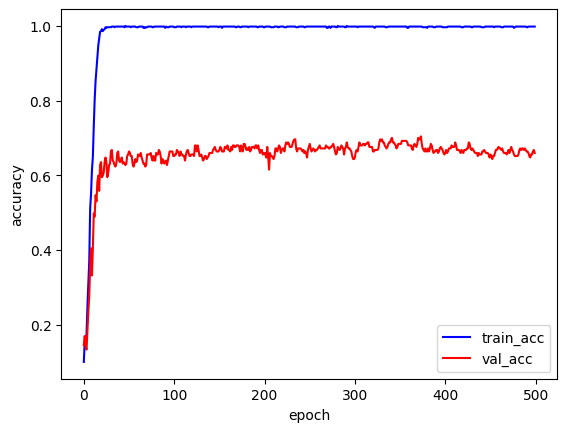

In [ ]:
history_dict2 = history_cnn2.history
acc_train_epochs = history_dict2['accuracy']
acc_val_epochs = history_dict2['val_accuracy']

plt.figure()
plt.plot(acc_train_epochs,color='blue',label='train_acc')
plt.plot(acc_val_epochs,color='red',label='val_acc')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()
plt.close()

#### Display the summary of your model and analyze the output (this step can be done before training)

In [ ]:
model_cnn2.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 255, 255, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 251, 251, 10)      760       
                                                                 
 max_pooling2d (MaxPooling2  (None, 125, 125, 10)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 121, 121, 20)      5020      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 60, 60, 20)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 72000)             0     

#### Choose saved model

In [ ]:
model_cnn2 = tf.keras.models.load_model('best-model.h5')

#### Evaluate model

In [ ]:
# evaluation on train
loss,acc = model_cnn2.evaluate(x_train,y_train,verbose=False)
print("Accuracy on train:",acc)

# evaluation on test
loss,acc = model_cnn2.evaluate(x_test,y_test,verbose=False)
print("Accuracy on test:",acc)

Accuracy on train: 0.8809234499931335
Accuracy on test: 0.5970873832702637
